In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
import plotly.graph_objects as go
from matplotlib.animation import FuncAnimation

dimension of X: (100, 2)
dimension of y: (100, 1)


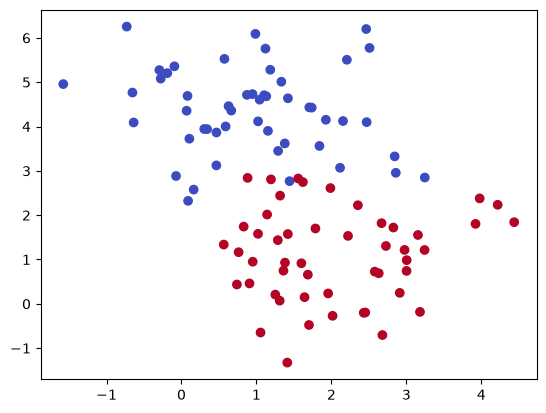

In [39]:
X,y = make_blobs(n_samples=100, n_features=2, random_state=0, centers=2)
y = y.reshape(y.shape[0], 1)

print('dimension of X:', X.shape)
print('dimension of y:', y.shape)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.show()

In [40]:
def initialize_parameters(x):
    w=np.random.rand(x.shape[1],1)
    b=np.random.rand(1)
    return(w,b)

In [41]:
def model(X, w, b):
    z=np.dot(X,w) +b
    A = 1/(1+np.exp(-z))
    return A

In [42]:
def log_loss(y, A):
    loss = -1/len(y)* np.sum(y*np.log(A) + (1-y)*np.log(1-A))
    return loss

In [43]:
def gradient_descent(A, X, y):
 dw = 1 / len(y) * np.dot(X.T, (A - y))
 db = 1 / len(y) * np.sum(A - y)
 return dw, db

In [44]:
def update_parameters(w, b, dw, db, learning_rate):
    w = w - learning_rate * dw
    b = b - learning_rate * db
    return (w, b)

In [ ]:
def predict(X, w, b):
    A = model(X, w, b)
    return A >= 0.5 

In [46]:
def artificial_neural_network(X, y, learning_rate=0.1, num_iterations=100):
    w, b = initialize_parameters(X)
    loss_history = []

    for i in range(num_iterations):
        A = model(X, w, b)
        loss_history.append(log_loss(y, A))
        dw, db = gradient_descent(A, X, y)
        w, b = update_parameters(w, b, dw, db, learning_rate)

    y_pred = predict(X, w, b)
    print('Précision :', np.mean(y_pred == y))
    plt.plot(loss_history)
    plt.xlabel('Itération')
    plt.ylabel('Coût')
    plt.show()

    return w, b

Précision : 0.9


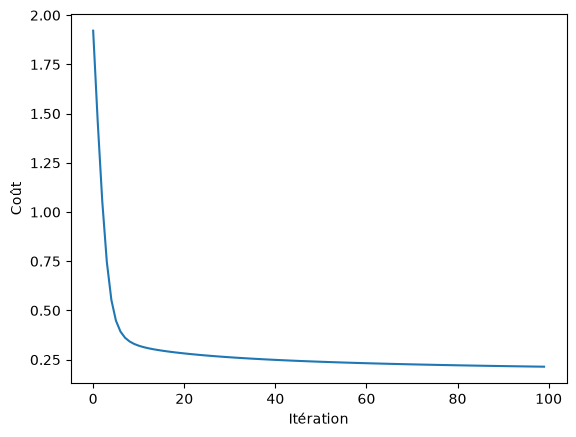

In [47]:
w, b = artificial_neural_network(X, y)

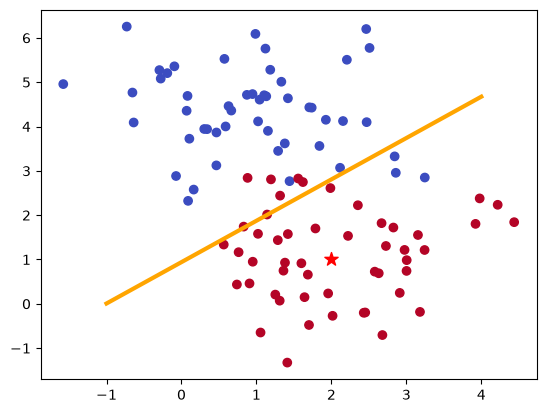

Probability of class 1: [[0.88384522]]
Predicted class: [[ True]]


In [48]:
new_plant = np.array([[2, 1]])
x0 = np.linspace(-1, 4, 100)
x1 = (-w[0] * x0 - b) / w[1]

plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='coolwarm')
plt.scatter(new_plant[0, 0], new_plant[0, 1], c='r', s=100, marker='*')
plt.plot(x0, x1, c='orange', lw=3)
plt.show()

print('Probability of class 1:', model(new_plant, w, b))
print('Predicted class:', predict(new_plant, w, b))

In [49]:

fig = go.Figure(data=[go.Scatter3d(
    x=X[:, 0].flatten(),
    y=X[:, 1].flatten(),
    z=y.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color=y.flatten(),
        colorscale='YlGn',
        opacity=0.8,
        reversescale=True
    )
)])

fig.update_layout(
    template='plotly_dark',
    margin=dict(l=0, r=0, t=0)
)

fig.layout.scene.camera.projection.type = 'orthographic'

fig.show()

In [51]:

x0 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x1 = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)

x0, x1 = np.meshgrid(x0, x1)

# Linear model
Z = w[0] * x0 + w[1] * x1 + b

# Sigmoid
A = 1 / (1 + np.exp(-Z))

# Create figure with probability surface
fig = go.Figure(data=[
    go.Surface(
        z=A,
        x=x0,
        y=x1,
        colorscale='YlGn',
        opacity=0.7,
        reversescale=True
    )
])

# Add data points
fig.add_scatter3d(
    x=X[:, 0].flatten(),
    y=X[:, 1].flatten(),
    z=y.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color=y.flatten(),
        colorscale='YlGn',
        opacity=0.9,
        reversescale=True
    )
)

# Layout
fig.update_layout(
    template='plotly_dark',
    margin=dict(l=0, r=0, t=0)
)

fig.layout.scene.camera.projection.type = 'orthographic'

fig.show()